# Analyze Dataset

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import scipy.stats as stats
from matplotlib.pyplot import figure
from sklearn.linear_model import LogisticRegression

## Goals
1) Load Dataset
2) Generate Target Values
3) Generate Demographic Features

## 01) Load Dataset

In [54]:
df_clean = pd.read_csv('intermediateData/cleanData.csv', index_col=0)
df_clean.head(1)

,Timestamp,What is your age group?,What is your gender?,What is your sexuality?,Where do you live?,What is your current occupation?,"Are you generally introverted, extroverted in real life?",How often do you browse r/Twice?,How did you discover r/Twice?,"Other than Twice, what other k-pop groups do you listen to?",...,x_ss_artm_mpp_memb_n_bit_2,x_ss_artm_mpp_memb_n_bit_3,x_xs_misc_pop_group_num,x_xs_misc_cvd_group_num,x_xs_misc_wop_group_num,x_xs_altm_pca_a1,x_xs_memb_pca_a1,x_xs_artm_pca_a1,x_xs_ms_clstr,x_xs_beha_evt_live_tour
0,12/26/2021 3:47:53,20-25,Female,Gay/Lesbian,North America,Unemployed,It depends who I'm around,A few times a month,Reddit Browsing,"BTS, EXO, ITZY, BlackPink, Red Velvet, SNSD, S...",...,1.0,0.0,1.0,0.0,0.0,0.52884,-0.02717,1.005668,0,1


In [55]:
target = "y_album_buying"

healing_feature_list = ["x_xs_demo_heal_group_num"]
album_buying_feature_list = ["x_xs_beha_alb_typ_group_num", "x_xs_beha_alb_cnt_group_num"] 

top_a_features = [
    # "x_xs_beha_evt_live",
    "x_xs_beha_evt_live_tour", # Not In final Version 
    "x_xs_demo_regi_group_num",
    #"x_xs_demo_heal_group_num",
    "x_xs_beha_mf_group_num",
    "x_xs_artm_mpp_memb_n",
    "x_xs_comp_dis_sent",
    "x_xs_demo_gen_group_num",
    "x_xs_comp_west_sent",
    "x_ss_artm_mpp_memb_n_bit_0",
    "x_xs_demo_vert_group_num", # Not In final Version 
    #"x_ss_demo_vert_middle", # Reduced
    #"x_ss_demo_vert_intro", # Reduced
    #"x_ss_demo_vert_depends", # Reduced
    #"x_ss_demo_vert_extro", # Reduced
    "x_xs_demo_role_student", # Not In final Version 
    "x_xs_demo_role_employed",
    #"x_ss_demo_role_stud_u",# Reduced
    #"x_ss_demo_role_prof_u",# Reduced
    #"x_ss_demo_role_stud_e",# Reduced
    #"x_ss_demo_role_prof_e",# Reduced
    "x_ss_demo_sex_other",
    #"x_mm_demo_regi_america_n", ,# Reduced
    "x_mm_altm_jglt_dy6",
    "x_ll_memb_soe_Dahyun_mnh",
    "x_ll_memb_soe_Jihyo_btd",
    "x_ll_memb_soe_Jihyo_loa",
    "x_ll_memb_soe_Sana_loa",
    "x_ll_memb_soe_Tzuyu_none",
    "x_ll_memb_soe_Jihyo_pds",
    "x_ll_memb_soe_Nayeon_sgl",
    # Extra Features
    #"x_xs_beha_evt_tour", # Repeate ,# Reduced
    "x_mm_demo_regi_america_c_s",  # Repeate
    "x_ll_memb_soe_Dahyun_knk", # Repeate
    "x_ll_memb_soe_Chaeyoung_csm",

    # New Extra Features
    "x_xs_comp_west_sent_japn", #

    ## Extra B Features
    # "x_xs_beha_evt_kcon",
    # "x_ll_memb_soe_Sana_yoy",
    # "x_mm_demo_regi_other_other",
    # "x_mm_demo_ag_000_014",
    # "x_ll_memb_soe_Dahyun_loa",


    ## Extra B Features for Healing
    # "x_xs_beha_browse_pm", # : 3
    # "x_mm_memb_cr_chaeyoung", #: 2
    # "x_ss_artm_mpp_memb_n_bit_3", ##, : 2
    # "x_ll_altm_omglt_allofthemnwhateverisgood", # : 2
    # "x_xs_artm_ovrl_cbk_n", #: 2
    # "x_mm_memb_fvt_shp_mina", #: 2

    ## PCA Features

    #### Alternative Music PCAs
    "x_xs_altm_pca_a1",

    #"x_xs_altm_pca_b1",
    #"x_xs_altm_pca_b2",

    #### Member PCAs
    "x_xs_memb_pca_a1",
    
    #"x_xs_memb_pca_b1",
    #"x_xs_memb_pca_b2",
    #"x_xs_memb_pca_b3",

    #### Artistic Medium PCAs
    "x_xs_artm_pca_a1",


    ## Classification Feature
    #"x_xs_km_clstr",
    ]

if target == "y_album_buying": # y_heal_b_kpop
    top_a_features = top_a_features + healing_feature_list

if target == "y_heal_b_kpop":
    top_a_features = top_a_features + album_buying_feature_list



In [56]:
#x_columns = [col for col in df_clean.columns if col.startswith('x_')]
x_columns = top_a_features
y_columns = [col for col in df_clean.columns if col.startswith('y_')]


In [65]:
len(x_columns)

28

In [57]:
df_clean = df_clean[y_columns + x_columns]
df_clean.head()

,y_album_buying,y_heal_b_kpop,x_xs_beha_evt_live_tour,x_xs_demo_regi_group_num,x_xs_beha_mf_group_num,x_xs_artm_mpp_memb_n,x_xs_comp_dis_sent,x_xs_demo_gen_group_num,x_xs_comp_west_sent,x_ss_artm_mpp_memb_n_bit_0,...,x_ll_memb_soe_Jihyo_pds,x_ll_memb_soe_Nayeon_sgl,x_mm_demo_regi_america_c_s,x_ll_memb_soe_Dahyun_knk,x_ll_memb_soe_Chaeyoung_csm,x_xs_comp_west_sent_japn,x_xs_altm_pca_a1,x_xs_memb_pca_a1,x_xs_artm_pca_a1,x_xs_demo_heal_group_num
0,1.0,1.0,1,6.0,60.0,6.0,5.0,0.0,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.528840,-0.027170,1.005668,2.0
1,1.0,1.0,2,6.0,6.0,6.0,5.0,1.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.422772,-0.803847,0.181624,2.0
2,0.0,0.0,0,1.0,12.0,4.0,5.0,1.0,2.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.021795,-0.396969,-1.044984,0.0
3,0.0,1.0,0,6.0,1.0,0.0,4.0,1.0,5.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.675254,0.204281,-0.870150,2.0
4,1.0,1.0,6,6.0,84.0,6.0,5.0,1.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.686089,1.418075,0.160196,2.0


Calculate Variance Inflation Factor (VIF)

In [58]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def calculate_vif(df, features=None):
    """
    Calculate VIF for each feature in the dataframe
    
    Parameters:
    df (pandas.DataFrame): The dataframe containing the features
    features (list, optional): List of features to calculate VIF for.
                              If None, uses all columns in df.
    
    Returns:
    pandas.DataFrame: A dataframe with features and their VIF values
    """
    # If no features specified, use all columns
    if features is None:
        features = df.columns
    
    # Create a dataframe with only the features
    X = df[features].copy()
    
    # Add a constant
    X = add_constant(X)
    
    # Calculate VIF for each feature
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    
    # Remove the constant from results
    vif_data = vif_data[vif_data['Feature'] != 'const']
    
    # Sort by VIF value (highest first)
    vif_data = vif_data.sort_values('VIF', ascending=False)
    
    return vif_data

# Example usage
vif_results = calculate_vif(df_clean, x_columns)
print(vif_results)

                        Feature       VIF
10       x_xs_demo_role_student  1.464999
11      x_xs_demo_role_employed  1.447360
16      x_ll_memb_soe_Jihyo_loa  1.421817
19      x_ll_memb_soe_Jihyo_pds  1.337652
4          x_xs_artm_mpp_memb_n  1.327211
2      x_xs_demo_regi_group_num  1.287122
8    x_ss_artm_mpp_memb_n_bit_0  1.276136
21   x_mm_demo_regi_america_c_s  1.230126
25             x_xs_altm_pca_a1  1.217224
13           x_mm_altm_jglt_dy6  1.198221
3        x_xs_beha_mf_group_num  1.196935
17       x_ll_memb_soe_Sana_loa  1.193983
15      x_ll_memb_soe_Jihyo_btd  1.181534
7           x_xs_comp_west_sent  1.175745
14     x_ll_memb_soe_Dahyun_mnh  1.175269
22     x_ll_memb_soe_Dahyun_knk  1.145462
6       x_xs_demo_gen_group_num  1.142456
20     x_ll_memb_soe_Nayeon_sgl  1.141532
24     x_xs_comp_west_sent_japn  1.139106
28     x_xs_demo_heal_group_num  1.116732
26             x_xs_memb_pca_a1  1.116278
18     x_ll_memb_soe_Tzuyu_none  1.088771
5            x_xs_comp_dis_sent  1

In [59]:
vif_results.head(30)

,Feature,VIF
10,x_xs_demo_role_student,1.464999
11,x_xs_demo_role_employed,1.447360
16,x_ll_memb_soe_Jihyo_loa,1.421817
19,x_ll_memb_soe_Jihyo_pds,1.337652
4,x_xs_artm_mpp_memb_n,1.327211
2,x_xs_demo_regi_group_num,1.287122
8,x_ss_artm_mpp_memb_n_bit_0,1.276136
21,x_mm_demo_regi_america_c_s,1.230126
25,x_xs_altm_pca_a1,1.217224
13,x_mm_altm_jglt_dy6,1.198221


In [60]:
#pip install seaborn
#pip install statsmodels

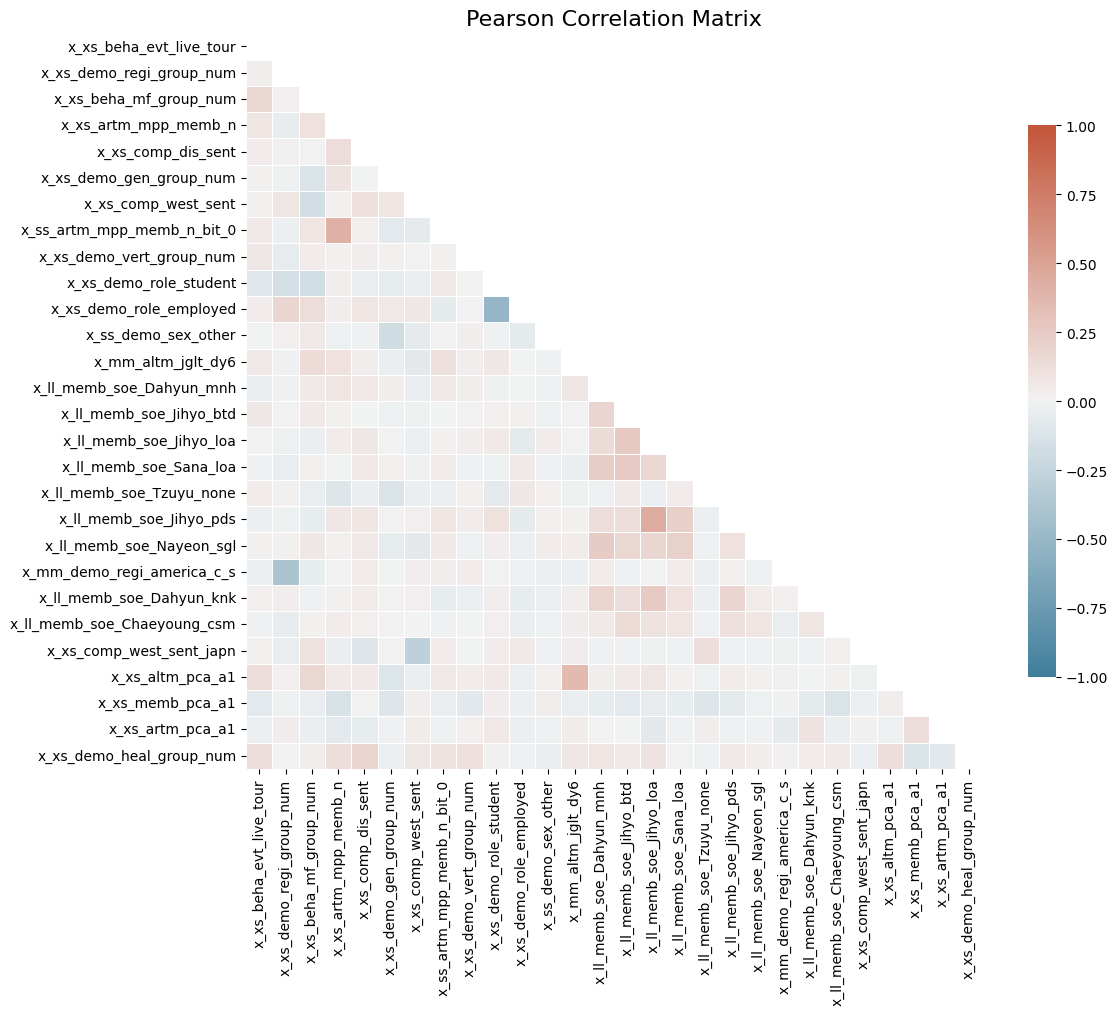

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def correlation_matrix(df, columns=None, method='pearson', threshold=None, figsize=(12, 10)):
    """
    Calculate and visualize the correlation matrix for selected columns
    
    Parameters:
    df (pandas.DataFrame): Input dataframe
    columns (list, optional): List of columns to include. If None, uses all numeric columns
    method (str, optional): Correlation method ('pearson', 'spearman', or 'kendall')
    threshold (float, optional): If set, only show correlations above this absolute value
    figsize (tuple, optional): Figure size for the heatmap
    
    Returns:
    pandas.DataFrame: The correlation matrix
    """
    # Select columns
    if columns is None:
        # Get only numeric columns
        columns = df.select_dtypes(include=[np.number]).columns
    
    # Calculate correlation matrix
    corr_matrix = df[columns].corr(method=method)
    
    # Filter by threshold if specified
    if threshold is not None:
        # Convert to numpy array for masking
        corr_values = corr_matrix.values
        # Create a mask for correlations below threshold (and diagonal)
        mask = np.abs(corr_values) < threshold
        np.fill_diagonal(mask, True)  # Mask the diagonal
        # Convert back to DataFrame
        filtered_corr = corr_matrix.copy()
        filtered_corr.values[mask] = np.nan
        display_matrix = filtered_corr
    else:
        display_matrix = corr_matrix
    
    # Visualization
    plt.figure(figsize=figsize)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Upper triangle mask
    cmap = sns.diverging_palette(230, 20, as_cmap=True)    # Red-blue color map
    
    # Plot heatmap without annotations
    sns.heatmap(
        corr_matrix, 
        mask=mask,
        cmap=cmap,
        vmax=1.0, 
        vmin=-1.0,
        center=0,
        square=True, 
        linewidths=.5,
        annot=False,  # No annotations
        cbar_kws={"shrink": .75}
    )
    plt.title(f"{method.capitalize()} Correlation Matrix", fontsize=16)
    plt.tight_layout()
    plt.show()
    
    return corr_matrix

# Example usage:
corr_matrix = correlation_matrix(df_clean, x_columns, threshold=0.7)

In [62]:
import pandas as pd
import numpy as np

def list_correlated_features(df, columns=None, method='pearson', threshold=0.7, sort=True):
    """
    Create a list of most correlated feature pairs in descending order
    
    Parameters:
    df (pandas.DataFrame): Input dataframe
    columns (list, optional): List of columns to include. If None, uses all numeric columns
    method (str, optional): Correlation method ('pearson', 'spearman', or 'kendall')
    threshold (float, optional): Only include correlations above this absolute value
    sort (bool, optional): Whether to sort by correlation strength (highest first)
    
    Returns:
    pandas.DataFrame: DataFrame containing feature pairs and their correlation values
    """
    # Select columns
    if columns is None:
        # Get only numeric columns
        columns = df.select_dtypes(include=[np.number]).columns
        
    # Calculate correlation matrix
    corr_matrix = df[columns].corr(method=method)
    
    # Extract upper triangle of correlation matrix (avoid duplicates)
    corr_pairs = []
    for i in range(len(columns)):
        for j in range(i+1, len(columns)):
            corr_value = corr_matrix.iloc[i, j]
            if abs(corr_value) >= threshold:
                corr_pairs.append({
                    'Feature_1': columns[i],
                    'Feature_2': columns[j],
                    'Correlation': corr_value
                })
    
    # Convert to DataFrame
    result = pd.DataFrame(corr_pairs)
    
    # Sort by absolute correlation value if requested
    if sort and not result.empty:
        result['Abs_Correlation'] = result['Correlation'].abs()
        result = result.sort_values('Abs_Correlation', ascending=False)
        result = result.drop('Abs_Correlation', axis=1)
        
    return result

# Example usage:
correlated_pairs = list_correlated_features(df_clean, x_columns, threshold=0.7)
print(correlated_pairs)

Empty DataFrame
Columns: []
Index: []


## Examine Coefficients

In [63]:
#bivariate = pd.crosstab(df_twice['x_xs_km_clstr'], df_twice['y_album_buying'], normalize='index').round(4) * 100
#bivariate

In [64]:
bivariate = pd.crosstab(df_twice[df_twice["split"]=='train']['x_xs_artm_mpp_memb_n'], df_twice[df_twice["split"]=='train']['y_album_buying'], normalize='index').round(4) * 100
bivariate

NameError: name 'df_twice' is not defined

In [ ]:

bivariate = pd.crosstab(df_twice[df_twice["split"]=='train']['x_xs_beha_mf_group_num'], df_twice[df_twice["split"]=='train']['y_album_buying'], normalize='index').round(4) * 100
bivariate

In [ ]:
bivariate = pd.crosstab(df_twice[df_twice["split"]=='train']['x_xs_comp_dis_sent'], df_twice[df_twice["split"]=='train']['y_album_buying'], normalize='index').round(4) * 100
bivariate

In [ ]:
bivariate = pd.crosstab(df_twice[df_twice["split"]=='train']['x_xs_comp_west_sent'], df_twice[df_twice["split"]=='train']['y_album_buying'], normalize='index').round(4) * 100
bivariate

In [ ]:
bivariate = pd.crosstab(df_twice[df_twice["split"]=='train']['x_xs_demo_regi_group_num'], df_twice[df_twice["split"]=='train']['y_album_buying'], normalize='index').round(4) * 100
bivariate